<a href="https://colab.research.google.com/github/rubusarbaro/supplychain-forecast-FIME/blob/main/Arima.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##############################################################################
###                           Modelo Arima                                  ##
###                        S&OP                                             ##
###                     11/03/2025                                          ##
###                                                   xoce15@ingenieros.com ##
##############################################################################

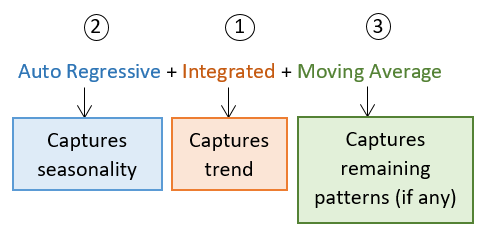


ARIMA (Media Móvil Autorregresiva Integrada) es un algoritmo estadístico que se utiliza para pronosticar valores futuros de una serie temporal.

Es una técnica muy utilizada para analizar series temporales.
Cómo funciona ARIMA Combina observaciones pasadas (AR), Diferencia para lograr estacionariedad (I), Utiliza errores pasados para afinar las predicciones (MA).

#Librerias

In [ ]:
import numpy as np, pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA


import warnings
warnings.filterwarnings('ignore')

# Parametros

In [ ]:
plt.rcParams.update({'figure.figsize':(9,7), 'figure.dpi':120})

# Funciones

In [ ]:
def forecast_accuracy(forecast, actual):
    mape = np.mean(np.abs(forecast - actual)/np.abs(actual))  # MAPE
    me = np.mean(forecast - actual)             # ME
    mae = np.mean(np.abs(forecast - actual))    # MAE
    mpe = np.mean((forecast - actual)/actual)   # MPE
    rmse = np.mean((forecast - actual)**2)**.5  # RMSE
    corr = np.corrcoef(forecast, actual)[0,1]   # corr
    mins = np.amin(np.hstack([forecast[:,None],
                              actual[:,None]]), axis=1)
    maxs = np.amax(np.hstack([forecast[:,None],
                              actual[:,None]]), axis=1)
    minmax = 1 - np.mean(mins/maxs)             # minmax
    acf1 = acf(fc-test)[1]                      # ACF1
    return({'mape':mape, 'me':me, 'mae': mae,
            'mpe': mpe, 'rmse':rmse, 'acf1':acf1,
            'corr':corr, 'minmax':minmax})

# Carga de datos

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/selva86/datasets/master/wwwusage.csv', names=['value'], header=0)

In [ ]:
df.head(2)

,value
0,88
1,84


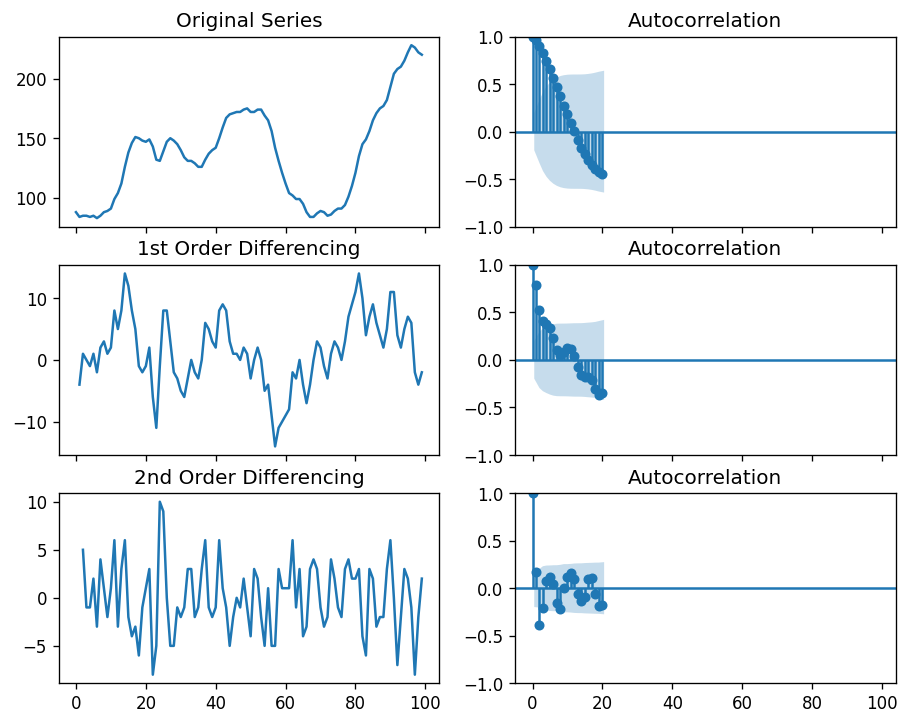

In [ ]:
# Original Series
fig, axes = plt.subplots(3, 2, sharex=True)
axes[0, 0].plot(df.value); axes[0, 0].set_title('Original Series')
plot_acf(df.value, ax=axes[0, 1])

# 1st Differencing
axes[1, 0].plot(df.value.diff()); axes[1, 0].set_title('1st Order Differencing')
plot_acf(df.value.diff().dropna(), ax=axes[1, 1])

# 2nd Differencing
axes[2, 0].plot(df.value.diff().diff()); axes[2, 0].set_title('2nd Order Differencing')
plot_acf(df.value.diff().diff().dropna(), ax=axes[2, 1])

plt.show()

Para la serie anterior, la serie temporal alcanza la estacionariedad con dos órdenes de diferenciación. Pero al observar el gráfico de autocorrelación para la segunda diferenciación, el retraso pasa bastante rápido a la zona negativa lejana, lo que indica que la serie podría haber sido sobrediferenciada.

Por lo tanto, se va a fijar tentativamente el orden de diferenciación en 1, aunque la serie no es perfectamente estacionaria (estacionariedad débil).

# Construir el Modelo Arima

Ahora que conoce los  valores de p, d y q, tiene todo lo necesario para ajustar el modelo ARIMA. Usando la implementación en package.ARIMA()statsmodels

In [ ]:
model = ARIMA(df.value, order=(1,1,2))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 2)   Log Likelihood                -254.126
Date:                Tue, 04 Mar 2025   AIC                            516.253
Time:                        22:05:13   BIC                            526.633
Sample:                             0   HQIC                           520.453
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6976      0.130      5.365      0.000       0.443       0.952
ma.L1          0.4551      0.169      2.699      0.007       0.125       0.786
ma.L2         -0.0664      0.157     -0.424      0.6

El resumen del modelo revela mucha información. La tabla del medio es la tabla de coeficientes donde los valores bajo 'coef' son los pesos de los términos respectivos.

Observe aquí que el coeficiente del término MA2 está cerca de cero y el valor P en 'P>|z|' columna es muy insignificante. Idealmente, debería ser inferior a 0,05 para que la X respectiva sea significativa.

Entonces, reconstruyamos el modelo sin el término MA2.

In [ ]:
model = ARIMA(df.value, order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -254.150
Date:                Tue, 04 Mar 2025   AIC                            514.300
Time:                        22:05:13   BIC                            522.086
Sample:                             0   HQIC                           517.450
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6504      0.090      7.258      0.000       0.475       0.826
ma.L1          0.5256      0.088      5.994      0.000       0.354       0.697
sigma2         9.7934      1.405      6.970      0.0

El modelo AIC se ha reducido, lo cual es bueno. Los Valores P de los términos AR1 y MA1 han mejorado y son altamente significativos (<< 0.05).

Grafiquemos los residuos para asegurarnos de que no haya patrones (es decir, busquemos la media y la varianza constantes).

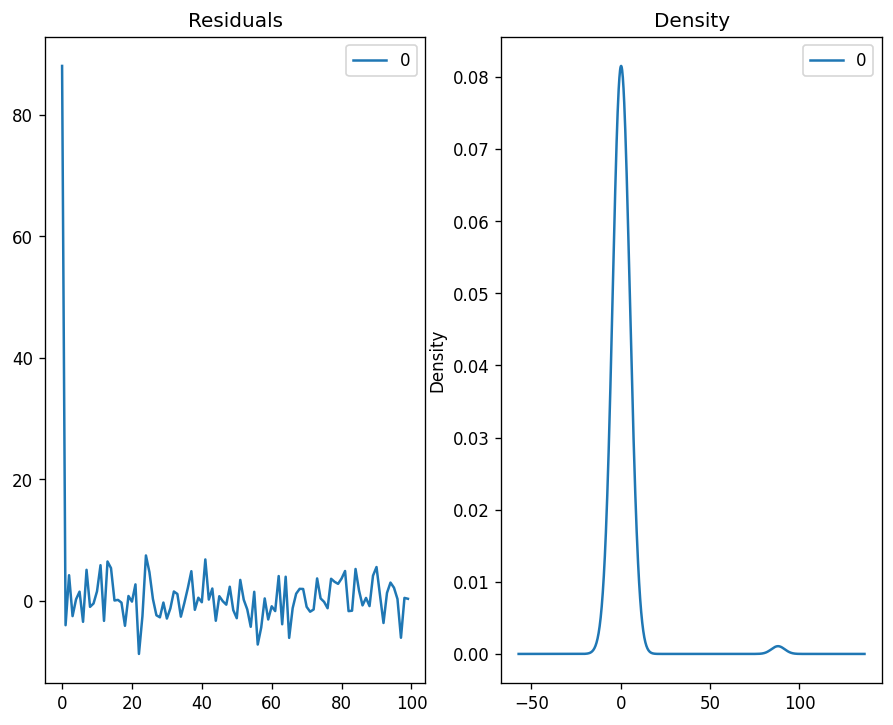

In [ ]:
residuals = pd.DataFrame(model_fit.resid)
fig, ax = plt.subplots(1,2)
residuals.plot(title="Residuals", ax=ax[0])
residuals.plot(kind='kde', title='Density', ax=ax[1])
plt.show()

Los errores residuales parecen correctos con una media cercana a cero y una varianza uniforme. Grafiquemos los datos reales contra los valores ajustados usando .plot_predict()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

fig = go.Figure()


fig.add_trace(go.Scatter( y=model_fit.predict(0,100), name='reales',
                            line = dict(color='olive', width=3)))

fig.add_trace(go.Scatter( y=df['value'], name='ARIMA',
                            line = dict(color='#8C000F', width=3, dash='dash')))
fig.update_layout(title= 'titles2', xaxis_title="index",yaxis_title="valor")

Cuando configura , los valores retrasados ​​en la muestra se utilizan para la predicción.dynamic=False

Es decir, el modelo se entrena hasta el valor anterior para realizar la siguiente predicción. Esto puede hacer que el pronóstico y los datos reales ajustados se vean artificialmente buenos.

Entonces, parece que tenemos un modelo ARIMA decente. ¿Pero es eso lo mejor?

No puedo decir eso en este momento porque en realidad no hemos pronosticado el futuro y comparado el pronóstico con el rendimiento real.

Entonces, la validación real que necesita ahora es la validación cruzada fuera del tiempo.

#Encontrar el modelo Arima Optimo

En la validación cruzada Out-of-Time, usted retrocede unos pasos en el tiempo y pronostica en el futuro tantos pasos como retrocedió. Luego compara el pronóstico con los datos reales.

Para realizar una validación cruzada fuera de tiempo, debe crear el conjunto de datos de entrenamiento y prueba dividiendo la serie temporal en 2 partes contiguas en una proporción de aproximadamente 75:25 o una proporción razonable basada en la frecuencia temporal de la serie.
¿Por qué no estoy muestreando los datos de entrenamiento al azar que preguntas?

Esto se debe a que la secuencia de orden de la serie temporal debe estar intacta para poder usarla para la previsión.

![image.png](https://miro.medium.com/v2/resize:fit:720/0*naxlpgZhSXuyAKxB.gif)

In [ ]:
from statsmodels.tsa.stattools import acf

# Creación de datos de entrenamiento y test
train = df.value[:85]
test = df.value[85:]

Ahora puede construir el modelo ARIMA en un conjunto de datos de entrenamiento, pronosticarlo y graficarlo

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   85
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -217.055
Date:                Tue, 04 Mar 2025   AIC                            440.109
Time:                        22:05:19   BIC                            447.402
Sample:                             0   HQIC                           443.041
                                 - 85                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6597      0.097      6.790      0.000       0.469       0.850
ma.L1          0.4857      0.099      4.892      0.000       0.291       0.680
sigma2        10.1098      1.595      6.340      0.0

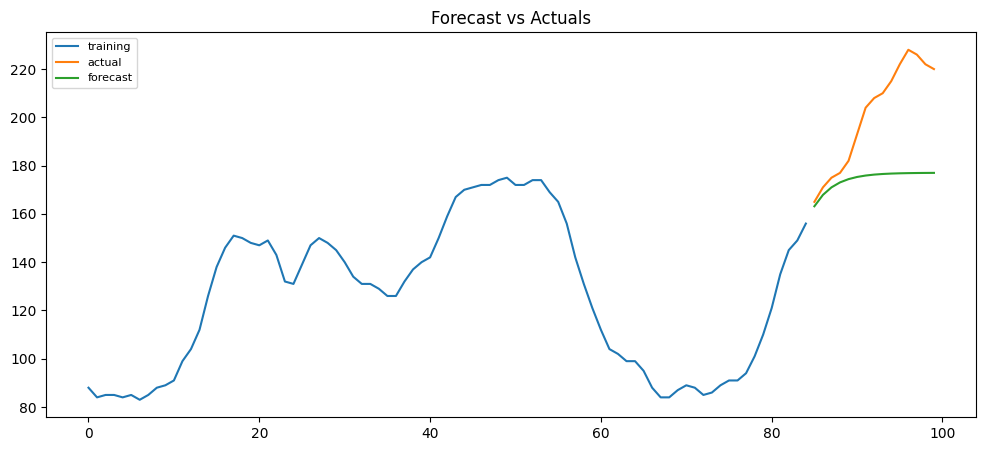

In [ ]:
# Construcción del modelo
# model = ARIMA(train, order=(3,2,1))
model = ARIMA(train, order=(1, 1, 1))
fitted = model.fit()
print(fitted.summary())

# prediccion
fc= fitted.forecast(15, alpha=0.05)  # 95% conf

# Make as pandas series
fc_series = pd.Series(fc, index=test.index)
#lower_series = pd.Series(conf[:, 0], index=test.index)
#upper_series = pd.Series(conf[:, 1], index=test.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
#plt.fill_between(lower_series.index, lower_series, upper_series,
#                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

In [ ]:
fig = go.Figure()

te= pd.DataFrame(test)
te.reset_index(inplace=True)

tra = pd.DataFrame(train)
tra.reset_index(inplace=True)


pre= pd.DataFrame(fc_series)
pre.reset_index(inplace=True)
pre.columns=['index','value']



fig.add_trace(go.Scatter( x=tra['index'] ,y=tra['value'], name='Training',
                            line = dict(color='olive', width=3)))

fig.add_trace(go.Scatter(x=te['index'],  y=te['value'], name='Test',
                            line = dict(color='#8C000F', width=3, dash='dash')))

fig.add_trace(go.Scatter(x=pre['index'],  y=pre['value'], name='Predict',
                            line = dict(color='blue', width=3, dash='dash')))

fig.update_layout(title= 'titles2', xaxis_title="index",yaxis_title="valor")

Del gráfico, el modelo ARIMA(1,1,1) parece dar un pronóstico direccionalmente correcto. Y los valores reales observados se encuentran dentro de la banda de confianza del 95%. Eso parece bien.

Pero cada uno de los pronósticos pronosticados está consistentemente por debajo de los reales. Eso significa que, al agregar una pequeña constante a nuestro pronóstico, la precisión ciertamente mejorará. Por lo tanto, definitivamente hay margen de mejora.

Entonces, lo que vamos  a hacer es aumentar el orden de diferenciación a dos, eso es establecer e iterativamente aumentar p hasta 5 y luego q hasta 5 para ver qué modelo da menos AIC.

Mientras se hace esto, se vigilao los valores P de los términos AR y MA en el resumen del modelo. Deberían estar lo más cerca posible de cero, idealmente, menos de 0,05.

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                   85
Model:                 ARIMA(3, 2, 1)   Log Likelihood                -214.430
Date:                Tue, 04 Mar 2025   AIC                            438.860
Time:                        22:05:23   BIC                            450.954
Sample:                             0   HQIC                           443.719
                                 - 85                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.1365      0.132      8.605      0.000       0.878       1.395
ar.L2         -0.5883      0.151     -3.896      0.000      -0.884      -0.292
ar.L3          0.3022      0.128      2.359      0.0

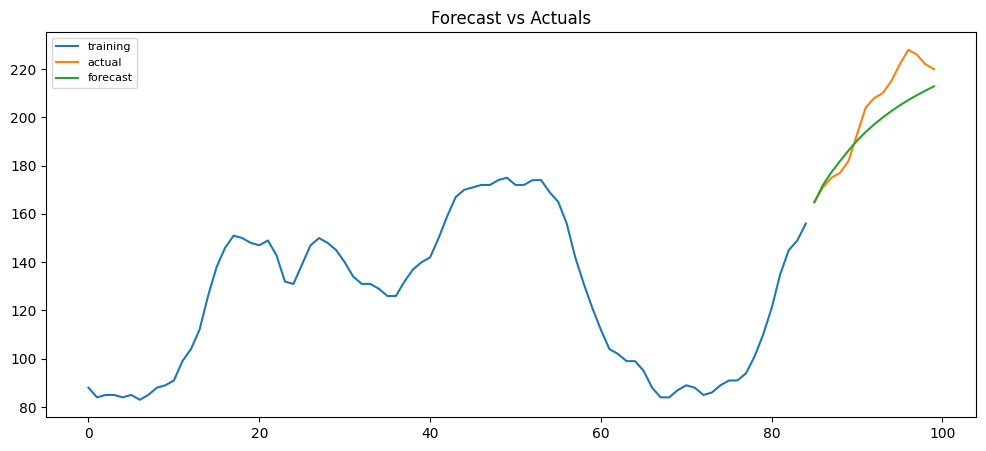

In [ ]:
# Construcción del modelo
model = ARIMA(train, order=(3, 2, 1))
fitted = model.fit()
print(fitted.summary())

# Forecast
fc = fitted.forecast(15, alpha=0.05)  # 95% conf

# Make as pandas series
fc_series = pd.Series(fc, index=test.index)
#lower_series = pd.Series(conf[:, 0], index=test.index)
#upper_series = pd.Series(conf[:, 1], index=test.index)

# Plot
plt.figure(figsize=(12,5), dpi=100)
plt.plot(train, label='training')
plt.plot(test, label='actual')
plt.plot(fc_series, label='forecast')
#plt.fill_between(lower_series.index, lower_series, upper_series,
#                 color='k', alpha=.15)
plt.title('Forecast vs Actuals')
plt.legend(loc='upper left', fontsize=8)
plt.show()

El AIC se ha reducido de 515 a 440. Bien. Los valores P de los términos X son menos < 0.05, lo cual es genial.

Así que en general es mucho mejor.

In [ ]:
fig = go.Figure()

te= pd.DataFrame(test)
te.reset_index(inplace=True)

tra = pd.DataFrame(train)
tra.reset_index(inplace=True)


pre= pd.DataFrame(fc_series)
pre.reset_index(inplace=True)
pre.columns=['index','value']



fig.add_trace(go.Scatter( x=tra['index'] ,y=tra['value'], name='Training',
                            line = dict(color='olive', width=3)))

fig.add_trace(go.Scatter(x=te['index'],  y=te['value'], name='Test',
                            line = dict(color='#8C000F', width=3, dash='dash')))

fig.add_trace(go.Scatter(x=pre['index'],  y=pre['value'], name='Predict',
                            line = dict(color='blue', width=3, dash='dash')))

fig.update_layout(title= 'titles2', xaxis_title="index",yaxis_title="valor")

# Metricas de precisión

In [ ]:
forecast_accuracy(np.array(fc),test.values)

{'mape': 0.04111144499125232,
 'me': -7.109342018536784,
 'mae': 8.76772041921795,
 'mpe': -0.031785085873371616,
 'rmse': 10.673099457011482,
 'acf1': 0.8588014582986138,
 'corr': 0.9734749070094333,
 'minmax': 0.04101263513980424}

Alrededor del 2,2 % de MAPE implica que el modelo tiene una precisión de alrededor del 97,8 % para predecir las próximas 15 observaciones.

Ahora ya sabe cómo construir un modelo ARIMA manualmente.

Pero en situaciones industriales, se le darán muchas series de tiempo para pronosticar y el ejercicio de pronóstico se repetirá regularmente.

Por lo tanto, necesitamos una forma de automatizar el mejor proceso de selección de modelos.